In [55]:
%load_ext autoreload
%autoreload 2
import torch 
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.manifold import Isomap, SpectralEmbedding
from sklearn.datasets import make_swiss_roll
from finsler_embedding.experiment_run import *
from finsler_embedding.disbm import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [56]:
N = 2000
noise = 0.1
beta=0.9
K = 400
function_type = "coordinates"

m=2
X, t = make_swiss_roll(n_samples=N, noise=noise)
X = torch.from_numpy(X).float()

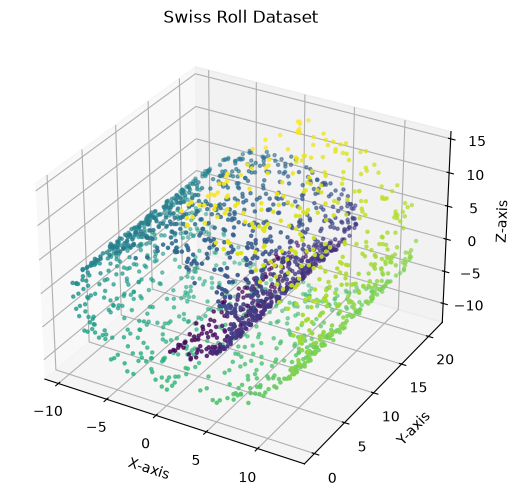

In [57]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax.set_title("Swiss Roll Dataset")
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
plt.show()

Text(0.5, 1.0, 'Swiss Roll Dataset (2D Projection)')

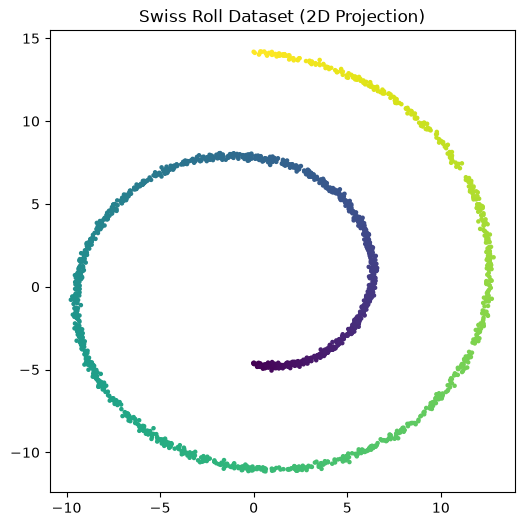

In [58]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X[:, 0], X[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax.set_title("Swiss Roll Dataset (2D Projection)")

In [59]:
base_cometric = IdentityCoMetric()
# base_cometric = CentroidsCometric(centroids=X, cometric_centroids=base_cometric(X))
# omega_true = get_omega("swiss_roll", cometric=base_cometric,dim=3)
omega_true = get_omega("swiss_roll_normal", cometric=base_cometric,dim=3)

randers_metric = RandersMetrics(
    base_cometric=base_cometric,
    omega=omega_true,
    beta=beta,
)
omega_true

OmegaSwissRollNormal(
  (cometric): IdentityCoMetric(coscale=1)
)

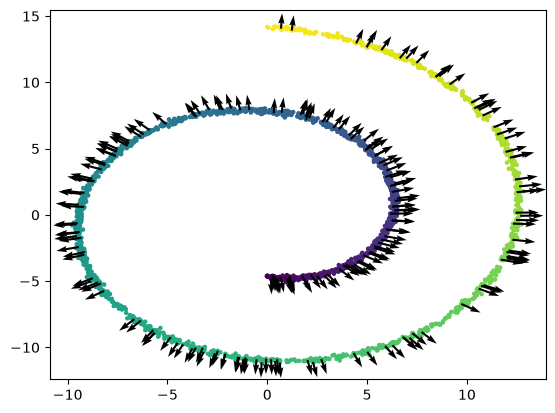

In [60]:

omega_x = omega_true(X)

skip=10
plt.scatter(X.detach()[:, 0], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
plt.quiver(X.detach()[::skip, 0], X.detach()[::skip, 2], omega_x.detach()[::skip, 0], omega_x.detach()[::skip, 2], 
           angles='xy', scale_units='xy')

In [61]:
b_true = randers_metric.omega(X) * randers_metric.beta
v_true = b_to_v(b_true, base_cometric.cometric_tensor(X)).detach()
v_true_norm = v_true.norm(dim=1)

In [62]:
edges = get_knn_graph(X, n_neighbors=10,device="cpu")
LOGGER.info(f"Found {edges.shape[0]} edges in the KNN graph.")
dst_edges = construct_distance_matrix(X, edges, randers_metric,use_approx=True)


[2026-09-16 18:13:21] - INFO - Found 22942 edges in the KNN graph.


Computing Randers distances:   0%|          | 0/230 [00:00<?, ?it/s]

Computing Randers distances: 100%|██████████| 230/230 [00:00<00:00, 3341.96it/s]


In [63]:
epsilon = compute_epsilon_empirical(dst_edges,scale=10)

W, mu_0, mu_1 = gaussian_kernel(edges, dst_edges, epsilon, N, m)
c_km = -mu_1 / mu_0 * (m + 1) / m
c_km = 1 / c_km

Q_inv_theta = get_Q_inv_theta(W, theta=1)
W_theta_s, W_theta_a = get_W_thetas(W, Q_inv_theta)
P_theta_s, P_theta_a = construct_P_thetas(W_theta_s, W_theta_a)
L_theta_s = 1 / epsilon**2 * P_theta_s
L_theta_a = 1 / epsilon * P_theta_a

In [64]:
# eigenvalues, eigenvectors = torch.linalg.eigh(L_theta_s)
# K = 2
# X_low = eigenvectors[:, :K] * eigenvalues[:K]

X_low = SpectralEmbedding(n_components=2, affinity='precomputed').fit_transform(W_theta_s.detach().cpu().numpy())
X_low = torch.from_numpy(X_low).float()


base_cometric_low = CentroidsCometric(centroids=X_low, cometric_centroids=IdentityCoMetric()(X_low))
base_cometric_low = IdentityCoMetric()

Text(0, 0.5, 'Y_low-axis')

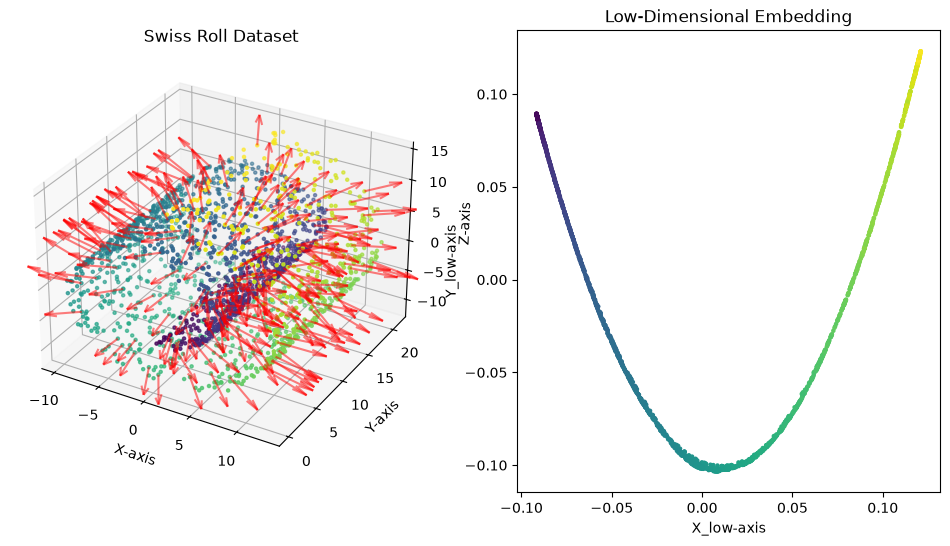

In [65]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           omega_x.detach()[::skip, 0], omega_x.detach()[::skip, 1], omega_x.detach()[::skip, 2],
           length=5, color='red', alpha=0.5)
           
ax1.set_title("Swiss Roll Dataset")
ax1.set_xlabel("X-axis")
ax1.set_ylabel("Y-axis")
ax1.set_zlabel("Z-axis")

ax2 = fig.add_subplot(122)
ax2.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1], c=t, cmap=plt.cm.viridis, s=5)
ax2.set_title("Low-Dimensional Embedding")
ax2.set_xlabel("X_low-axis")
ax2.set_ylabel("Y_low-axis")

[2026-09-16 18:13:23] - INFO - Training vector field models...


Loss: 2.7240e-02:   0%|          | 0/1000 [00:00<?, ?it/s]

Loss: 3.1595e-05: 100%|██████████| 1000/1000 [00:02<00:00, 420.18it/s]


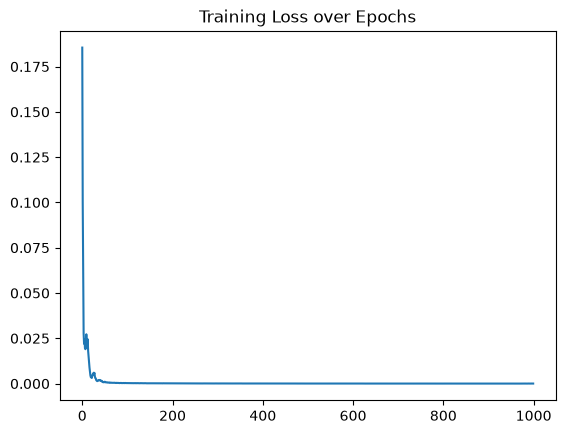

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 2479.096435546875,
 'std': 18066.234375,
 'min': 0.08751179277896881,
 'max': 746808.375,
 'quantile_5': 29.17071533203125,
 'quantile_25': 172.493896484375,
 'median': 435.78741455078125,
 'quantile_75': 1131.358642578125,
 'quantile_95': 6861.84228515625}

In [66]:
# High dim learning
f_values_high, Lf_values_high, f_grad_values_high = prepare_test_functions(
        K, function_type, X, L_theta_a
    )
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X, base_cometric, c_km, f_values_high, Lf_values_high, f_grad_values_high,m=3
)
v_hat_deep_high = v_model(X).detach()
b_hat_deep_high = omega_model(X).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep_high, f_grad_values_high)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values_high) > 1e-8, torch.abs(Lf_values_high - rhs) / torch.abs(Lf_values_high) * 100, torch.zeros_like(Lf_values_high))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

In [67]:
b_norm = base_cometric.cometric(X, b_true).detach()
b_deep_high_norm = base_cometric.cometric(X, b_hat_deep_high).detach()
b_norm.mean(), b_deep_high_norm.mean(), b_deep_high_norm.std(), b_deep_high_norm.max()

(tensor(0.9000), tensor(0.0098), tensor(0.0048), tensor(0.0275))

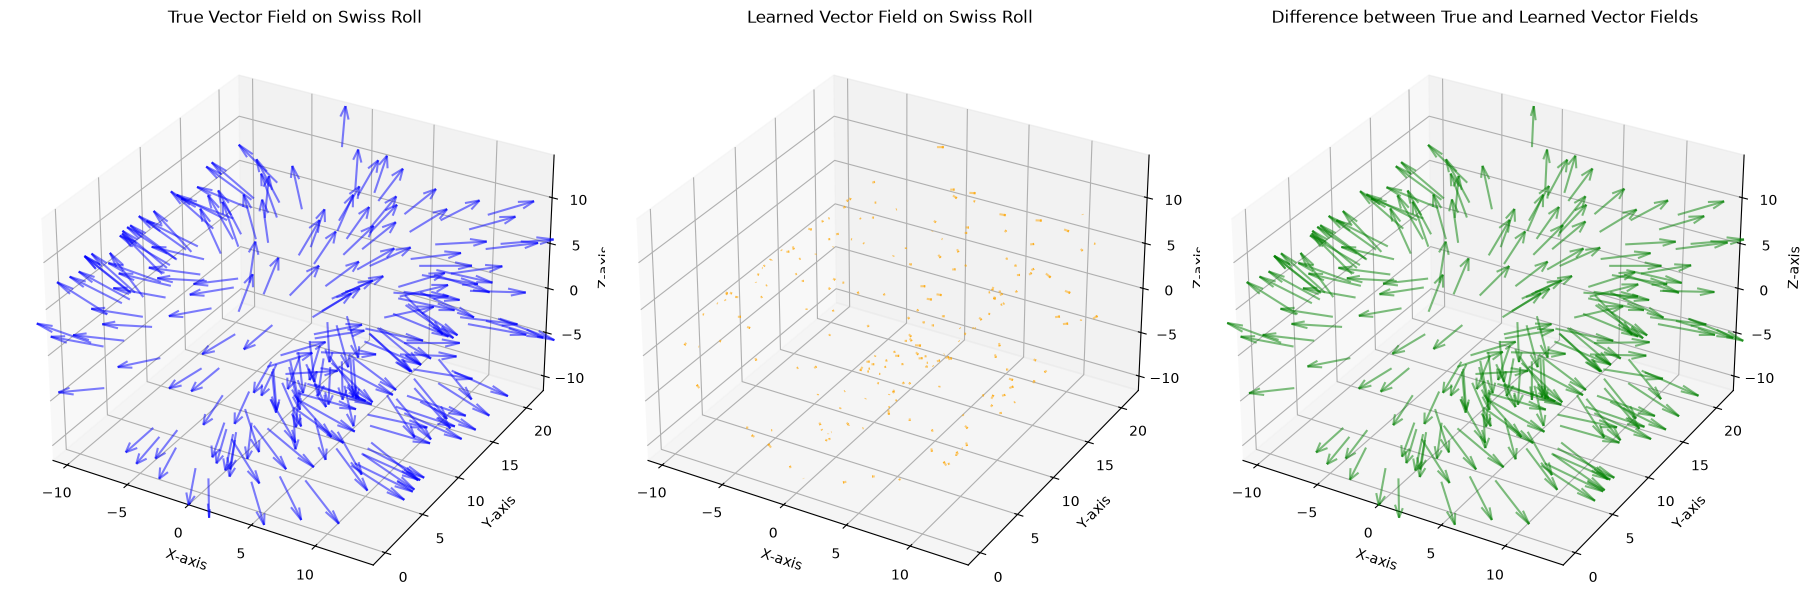

In [68]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
# ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_true.detach()[::skip, 0], b_true.detach()[::skip, 1], b_true.detach()[::skip, 2],
           length=5, color='blue', alpha=0.5)
ax1.set_title("True Vector Field on Swiss Roll")

ax2 = fig.add_subplot(132, projection='3d')
# ax2.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax2.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_hat_deep_high[::skip, 0], b_hat_deep_high[::skip, 1], b_hat_deep_high[::skip, 2],
           length=20, color='orange', alpha=0.5)
ax2.set_title("Learned Vector Field on Swiss Roll")

delta_b = (b_true - b_hat_deep_high).detach()
ax3 = fig.add_subplot(133, projection='3d')
# ax3.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax3.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           delta_b[::skip, 0], delta_b[::skip, 1], delta_b[::skip, 2],
           length=5, color='green', alpha=0.5)
ax3.set_title("Difference between True and Learned Vector Fields")  

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("X-axis")
    ax.set_ylabel("Y-axis")
    ax.set_zlabel("Z-axis")

plt.tight_layout()
plt.show()

# Low dim learning

In [69]:
f_values_low, Lf_values_low, f_grad_values_low = prepare_test_functions(
        K, function_type, X_low, L_theta_a
    )

[2026-09-16 18:13:26] - INFO - Training vector field models...


Loss: 2.1019e-04:   0%|          | 3/1000 [00:00<00:36, 27.09it/s]

Loss: 1.9481e-09: 100%|██████████| 1000/1000 [00:02<00:00, 472.84it/s]


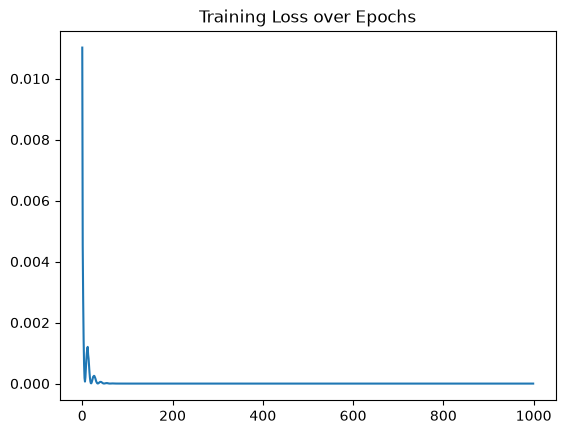

Relative Error (%) Statistics on the prediction of the operator:


{'mean': 5395.8076171875,
 'std': 27622.9375,
 'min': 0.0,
 'max': 814047.875,
 'quantile_5': 47.02685546875,
 'quantile_25': 223.65765380859375,
 'median': 769.62890625,
 'quantile_75': 2219.765625,
 'quantile_95': 17370.013671875}

In [70]:
LOGGER.info("Training vector field models...")
v_model, omega_model, loss_list = train_vector_field_models(
    X_low, base_cometric_low, c_km, f_values_low, Lf_values_low, f_grad_values_low
)
v_hat_deep_low = v_model(X_low).detach()
b_hat_deep_low = omega_model(X_low).detach()
plt.plot(loss_list)
plt.title("Training Loss over Epochs")
plt.show()

# Compute relative error:
rhs = c_km * torch.einsum('n d, k n d -> k n', v_hat_deep_low, f_grad_values_low)  # (1, N)
relative_error = torch.where(torch.abs(Lf_values_low) > 1e-8, torch.abs(Lf_values_low - rhs) / torch.abs(Lf_values_low) * 100, torch.zeros_like(Lf_values_low))
print(f"Relative Error (%) Statistics on the prediction of the operator:")
qqt_summary_statistics(relative_error.flatten())

In [71]:
base_cometric_low.cometric(X_low,b_hat_deep_low).max() # Ptdr wtf

tensor(0.0001)

Text(0.5, 1.0, 'Learned Vector Field on Low-Dimensional Embedding')

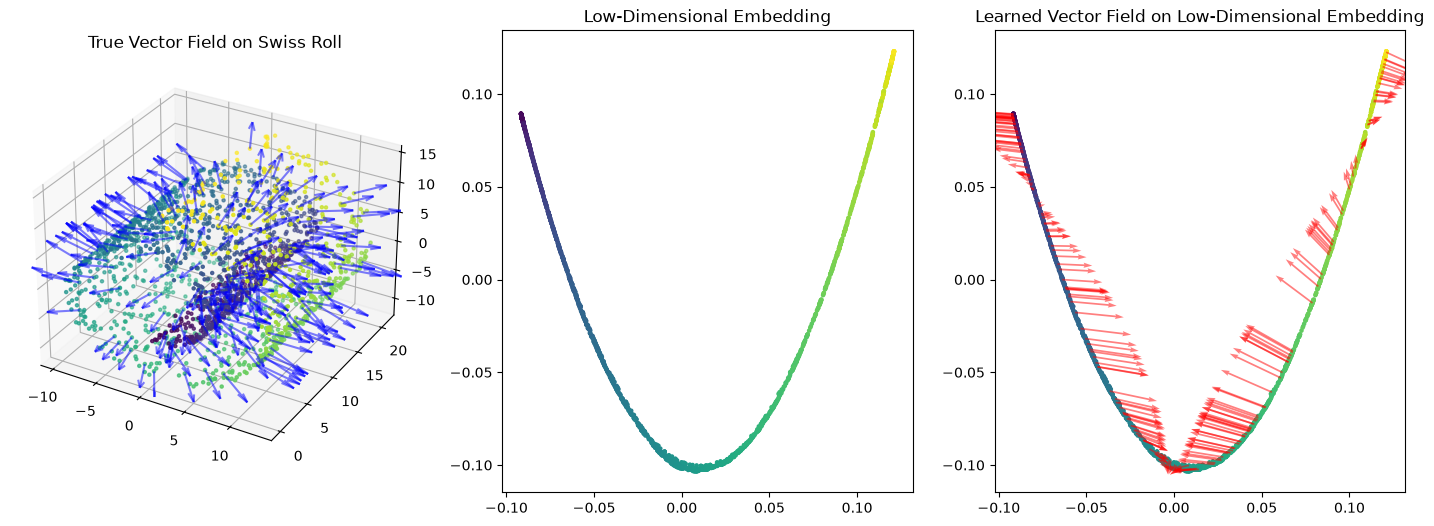

In [72]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X.detach()[:, 0], X.detach()[:, 1], X.detach()[:, 2], c=t, cmap=plt.cm.viridis, s=5)
ax1.quiver(X.detach()[::skip, 0], X.detach()[::skip, 1], X.detach()[::skip, 2], 
           b_true.detach()[::skip, 0], b_true.detach()[::skip, 1], b_true.detach()[::skip, 2],
           length=5, color='blue', alpha=0.5)
ax1.set_title("True Vector Field on Swiss Roll")

ax2 = fig.add_subplot(132)
ax2.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1], c=t, cmap=plt.cm.viridis, s=5)
ax2.set_title("Low-Dimensional Embedding")

ax3 = fig.add_subplot(133)
ax3.scatter(X_low.detach()[:, 0], X_low.detach()[:, 1], c=t, cmap=plt.cm.viridis, s=5)
ax3.quiver(X_low.detach()[::skip, 0], X_low.detach()[::skip, 1], 
           b_hat_deep_low[::skip, 0], b_hat_deep_low[::skip, 1],
           angles='xy', scale_units='xy', scale=0.004, color='red', alpha=0.5)
ax3.set_title("Learned Vector Field on Low-Dimensional Embedding")